In [15]:
# connecting to Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Problem 02: **Message Sentiment Classification** using transfer learning for Transformer
### By: Ayushman Anupam (MDS202411)

This project develops a sentiment classification system for text messages using transfer learning with a pre-trained Transformer model. A labeled dataset containing negative, neutral, and positive sentiments is used for training, validation, and testing.

The text data is tokenized and converted into model-compatible inputs using a Transformer tokenizer. A pre-trained BERT-based model is then fine-tuned by adapting its classification head to predict three sentiment classes. The model leverages contextual understanding from pre-training while learning task-specific patterns from the dataset.

The model is trained using GPU acceleration and evaluated on unseen test data using accuracy, precision, recall, and F1-score. Additionally, training and validation loss and accuracy are tracked across epochs to monitor performance, and sample predictions are visualized to better understand model behavior.


In [16]:
# importing needed libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import textwrap
from sklearn.model_selection import train_test_split

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torch.optim as optim

from transformers import BertTokenizer, BertForSequenceClassification
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

import warnings
warnings.filterwarnings('ignore')

# Paths
BASE_PATH = "/content/drive/Othercomputers/My Laptop/AGDrive/Applied_Machine_Learning/Assignment 05"
# BASE_PATH = ""

In [17]:
# loading Data
train_data_path = os.path.join(BASE_PATH, "Problem02_Dataset", "train.csv")
test_data_path = os.path.join(BASE_PATH, "Problem02_Dataset", "test.csv")

df_train = pd.read_csv(train_data_path, encoding="latin1")
df_test = pd.read_csv(test_data_path, encoding="latin1")

In [18]:
df_train.head()

,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,morning,0-20,Afghanistan,38928346,652860.0,60
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,noon,21-30,Albania,2877797,27400.0,105
2,088c60f138,my boss is bullying me...,bullying me,negative,night,31-45,Algeria,43851044,2381740.0,18
3,9642c003ef,what interview! leave me alone,leave me alone,negative,morning,46-60,Andorra,77265,470.0,164
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,noon,60-70,Angola,32866272,1246700.0,26


#### Cleaning the Data and removing N/A value

In [19]:
def clean_and_report_nas(df, name):
    print(f"------ for {name} ------")
    df_subset = df[['text', 'sentiment']].copy()
    print("Removed all rows except 'text'and 'sentiment'")

    initial_nas = df_subset.isnull().sum().sum()
    print(f"Total NA values before cleaning: {initial_nas}")
    df_cleaned = df_subset.dropna()
    final_nas = df_cleaned.isnull().sum().sum()
    print(f"Total NA values after cleaning:  {final_nas}")

    final_rows = df_cleaned.shape[0]
    print(f"Total number of rows remaining:  {final_rows}\n")

    return df_cleaned

train_data = clean_and_report_nas(df_train, "Train Data")
test_data = clean_and_report_nas(df_test, "Test Data")

------ for Train Data ------
Removed all rows except 'text'and 'sentiment'
Total NA values before cleaning: 1
Total NA values after cleaning:  0
Total number of rows remaining:  27480

------ for Test Data ------
Removed all rows except 'text'and 'sentiment'
Total NA values before cleaning: 2562
Total NA values after cleaning:  0
Total number of rows remaining:  3534



### Splitting Train set into train and validation dataset

In [20]:
train_data, validation_data = train_test_split(
    train_data,
    test_size=3480,
    random_state=42,
    stratify=train_data['sentiment']
)

print(f"New Train shape: {train_data.shape}")
print(f"Validation shape: {validation_data.shape}")

print("\nTrain distribution:")
print(train_data['sentiment'].value_counts(normalize=True))

print("\nValidation distribution:")
print(validation_data['sentiment'].value_counts(normalize=True))

print("\nTest distribution:")
print(test_data['sentiment'].value_counts(normalize=True))

New Train shape: (24000, 2)
Validation shape: (3480, 2)

Train distribution:
sentiment
neutral     0.404542
positive    0.312292
negative    0.283167
Name: proportion, dtype: float64

Validation distribution:
sentiment
neutral     0.404598
positive    0.312356
negative    0.283046
Name: proportion, dtype: float64

Test distribution:
sentiment
neutral     0.404641
positive    0.312111
negative    0.283248
Name: proportion, dtype: float64


### Distribution of class in train, validation and test dataset

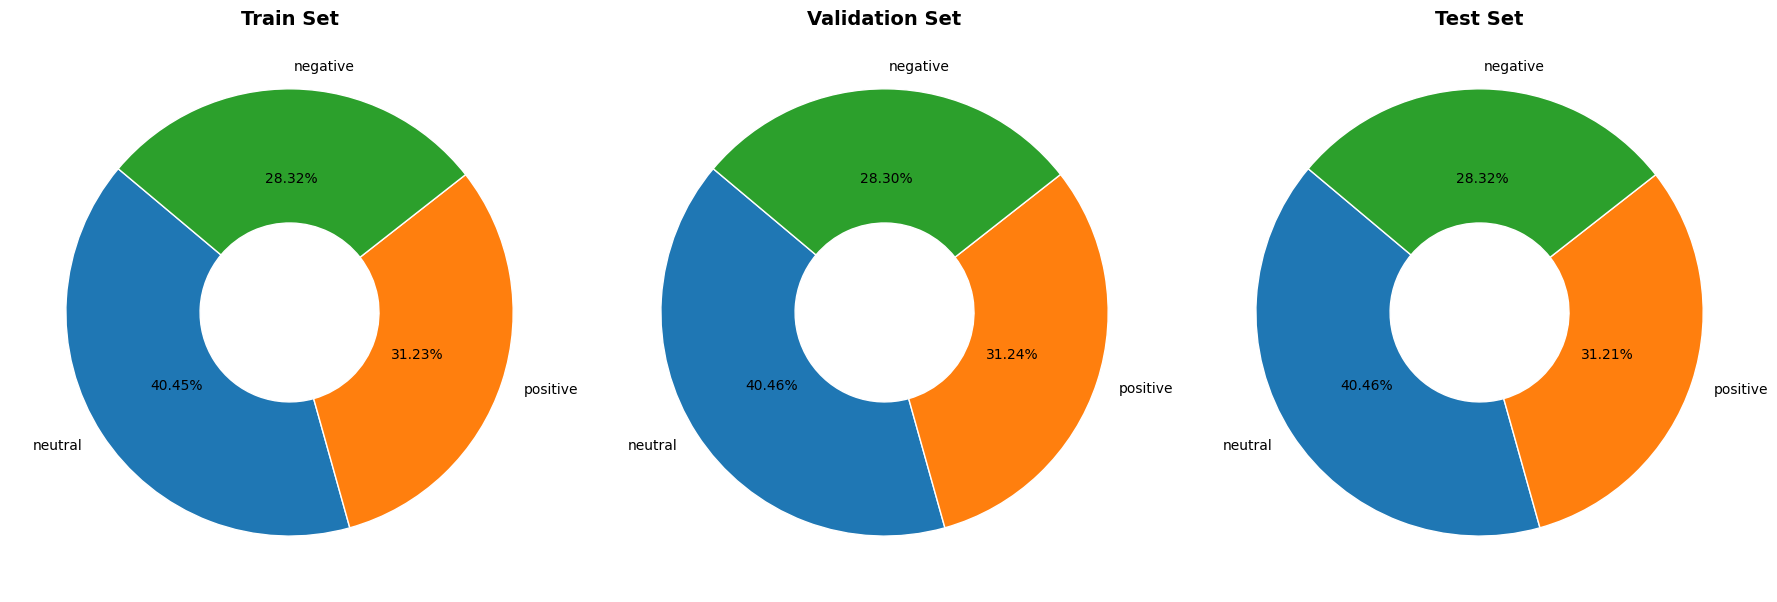

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

datasets = [
    (train_data, "Train Set"),
    (validation_data, "Validation Set"),
    (test_data, "Test Set")
]

for i, (df, title) in enumerate(datasets):
    counts = df['sentiment'].value_counts()

    # Plot donut chart
    axes[i].pie(
        counts,
        labels=counts.index,
        autopct='%1.2f%%',
        startangle=140,
        wedgeprops={'width': 0.6, 'edgecolor': 'w'}
    )

    axes[i].set_title(title, fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [22]:
# Label encoding
label_map = {'positive': 2, 'neutral': 1, 'negative': 0}
train_data['label'] = train_data['sentiment'].map(label_map)
test_data['label'] = test_data['sentiment'].map(label_map)
validation_data['label'] = validation_data['sentiment'].map(label_map)

### Custom DataSet function for transformer

In [23]:
class CustomDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(0),       # remove batch dim
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [24]:
# training device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## Pretrained Model

In [25]:
# Load tokenizer
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# Load model for classification (3 labels: negative, neutral, positive)
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=3
)
model.to(device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [26]:
train_dataset = CustomDataset(train_data['text'].tolist(), train_data['label'].tolist(), tokenizer)
test_dataset = CustomDataset(test_data['text'].tolist(), test_data['label'].tolist(), tokenizer)
validation_daset = CustomDataset(validation_data['text'].tolist(), validation_data['label'].tolist(), tokenizer)


batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
validation_loader = DataLoader(validation_daset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)


#### Hyperparameters for training

In [27]:
epochs = 11
learning_rate = 2e-5
optimizer = optim.AdamW(model.parameters(), lr=learning_rate)

### **Training**

In [28]:
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

for epoch in range(epochs):
    # Training
    model.train()
    total_loss = 0.0
    total_batches = 0

    all_preds = []
    all_labels = []

    for batch_idx, batch in enumerate(train_loader):
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        logits = outputs.logits

        total_loss += loss.item()
        total_batches += 1

        loss.backward()
        optimizer.step()

        # Predictions
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        if batch_idx % 100 == 99:
            print(f"Epoch {epoch+1}/{epochs}, Batch {batch_idx+1}/{len(train_loader)}, Loss: {loss.item():.6f}")

    avg_train_loss = total_loss / total_batches
    train_acc = accuracy_score(all_labels, all_preds)

    train_losses.append(avg_train_loss)
    train_accuracies.append(train_acc)

    # validation
    model.eval()
    val_loss = 0.0
    val_batches = 0

    val_preds = []
    val_labels = []

    with torch.no_grad():
        for batch in validation_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            logits = outputs.logits

            val_loss += loss.item()
            val_batches += 1

            preds = torch.argmax(logits, dim=1)
            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    avg_val_loss = val_loss / val_batches
    val_acc = accuracy_score(val_labels, val_preds)

    val_losses.append(avg_val_loss)
    val_accuracies.append(val_acc)


    # Epoch summary
    print(f"\n -------- Epoch {epoch+1}/{epochs} summary --------")
    print(f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {avg_val_loss:.4f} | Val   Acc: {val_acc:.4f}")
    print('\n',"-"*38,'\n')

Epoch 1/11, Batch 100/375, Loss: 0.526334
Epoch 1/11, Batch 200/375, Loss: 0.469628
Epoch 1/11, Batch 300/375, Loss: 0.621697

 -------- Epoch 1/11 summary --------
Train Loss: 0.6069 | Train Acc: 0.7421
Val   Loss: 0.5232 | Val   Acc: 0.7911

 -------------------------------------- 

Epoch 2/11, Batch 100/375, Loss: 0.571755
Epoch 2/11, Batch 200/375, Loss: 0.330309
Epoch 2/11, Batch 300/375, Loss: 0.440876

 -------- Epoch 2/11 summary --------
Train Loss: 0.4369 | Train Acc: 0.8260
Val   Loss: 0.5300 | Val   Acc: 0.7971

 -------------------------------------- 

Epoch 3/11, Batch 100/375, Loss: 0.308364
Epoch 3/11, Batch 200/375, Loss: 0.501170
Epoch 3/11, Batch 300/375, Loss: 0.211207

 -------- Epoch 3/11 summary --------
Train Loss: 0.3274 | Train Acc: 0.8776
Val   Loss: 0.5886 | Val   Acc: 0.7805

 -------------------------------------- 

Epoch 4/11, Batch 100/375, Loss: 0.182688
Epoch 4/11, Batch 200/375, Loss: 0.327927
Epoch 4/11, Batch 300/375, Loss: 0.270113

 -------- Epoch

#### Performance improvement along epoch plot

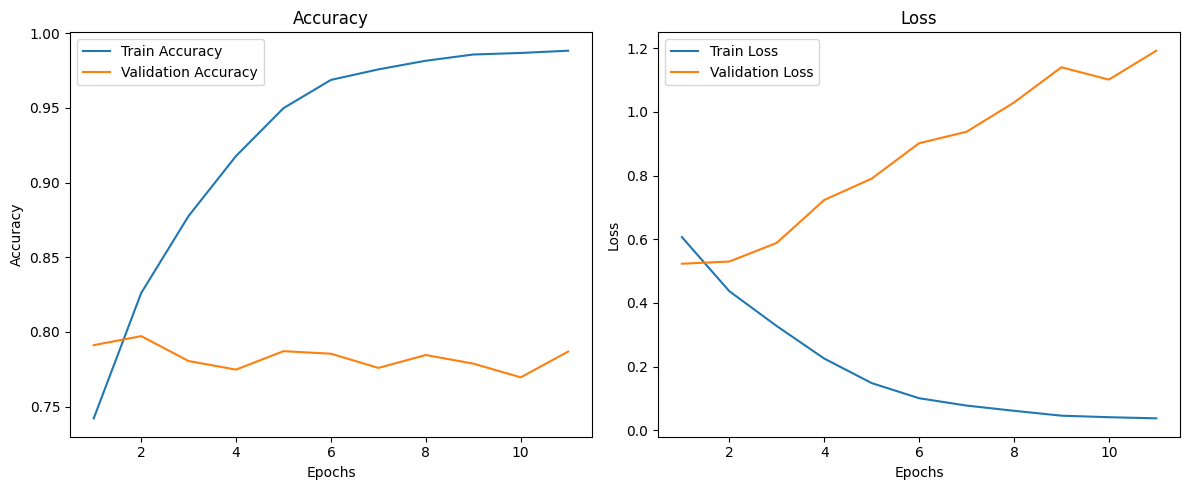

In [29]:
epochs_range = range(1, epochs + 1)

plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_accuracies, label='Train Accuracy')
plt.plot(epochs_range, val_accuracies, label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy")
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_losses, label='Train Loss')
plt.plot(epochs_range, val_losses, label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss")
plt.legend()

plt.tight_layout()
plt.show()

### Model Evaluation on test Dataset

In [30]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [31]:
# Overall
accuracy = accuracy_score(all_labels, all_preds)
precision_macro = precision_score(all_labels, all_preds, average='macro')
recall_macro = recall_score(all_labels, all_preds, average='macro')
f1_macro = f1_score(all_labels, all_preds, average='macro')

# Per-class metrics
precision_per_class = precision_score(all_labels, all_preds, average=None)
recall_per_class = recall_score(all_labels, all_preds, average=None)
f1_per_class = f1_score(all_labels, all_preds, average=None)

# Per-class accuracy
all_labels = np.array(all_labels)
all_preds = np.array(all_preds)

class_accuracy = []
num_classes = 3

for i in range(num_classes):
    idx = (all_labels == i)
    acc_i = (all_preds[idx] == all_labels[idx]).mean()
    class_accuracy.append(acc_i)

metric_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Whole Test Set": [ accuracy, precision_macro, recall_macro, f1_macro],
    "Negative": [class_accuracy[0], precision_per_class[0], recall_per_class[0], f1_per_class[0]],
    "Neutral": [class_accuracy[1], precision_per_class[1], recall_per_class[1], f1_per_class[1]],
    "Positive": [class_accuracy[2], precision_per_class[2], recall_per_class[2], f1_per_class[2]]
})

metric_df

,Metric,Whole Test Set,Negative,Neutral,Positive
0,Accuracy,0.781834,0.759241,0.785315,0.797824
1,Precision,0.790812,0.799159,0.728748,0.844530
2,Recall,0.780793,0.759241,0.785315,0.797824
3,F1-score,0.785059,0.778689,0.755974,0.820513


In [32]:
print(classification_report(all_labels, all_preds, target_names=['negative', 'neutral', 'positive'], digits = 6))

              precision    recall  f1-score   support

    negative   0.799159  0.759241  0.778689      1001
     neutral   0.728748  0.785315  0.755974      1430
    positive   0.844530  0.797824  0.820513      1103

    accuracy                       0.781834      3534
   macro avg   0.790812  0.780793  0.785059      3534
weighted avg   0.784828  0.781834  0.782551      3534



### Sample Classification

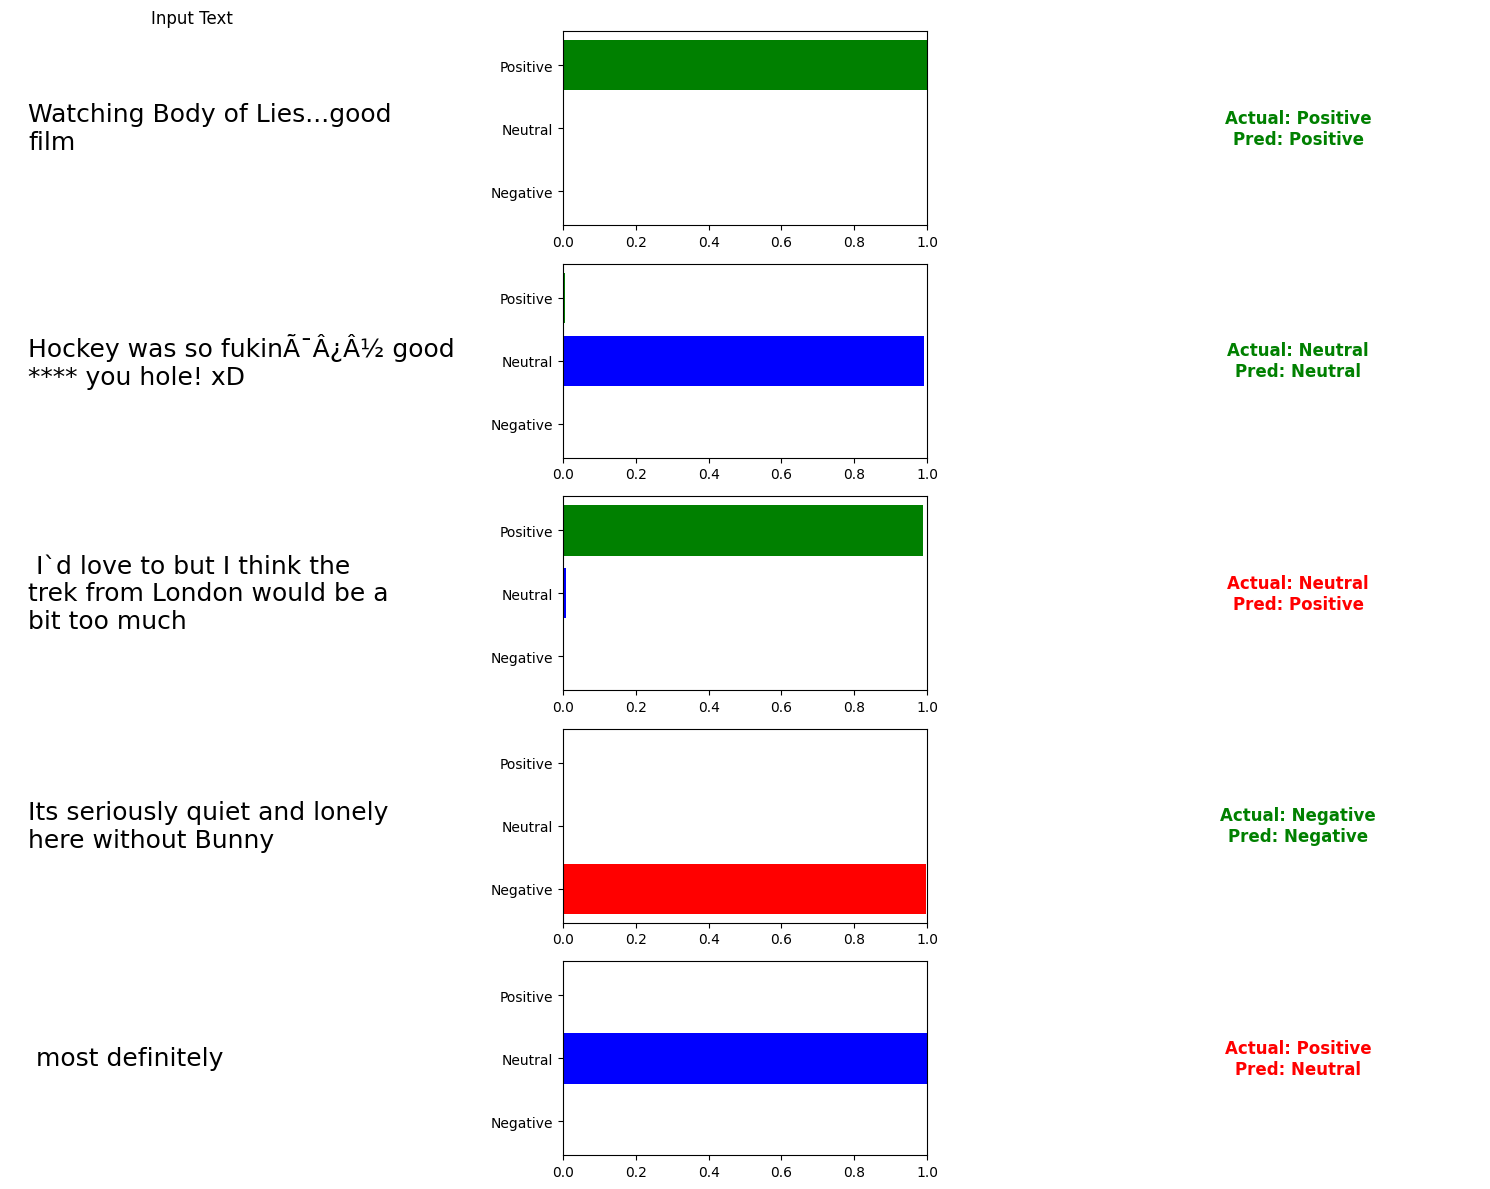

In [35]:
class_names = ["Negative", "Neutral", "Positive"]
color_map = {"Negative": "red", "Neutral": "blue", "Positive": "green"}

indices = random.sample(range(len(test_data)), 5)
fig, ax = plt.subplots(5, 3, figsize=(15, 12)) # Increased height slightly for wrapped text

model.eval()

for i, idx in enumerate(indices):
    sample = test_dataset[idx]
    input_ids = sample["input_ids"].unsqueeze(0).to(device)
    attention_mask = sample["attention_mask"].unsqueeze(0).to(device)
    label = sample["labels"].item()

    text = test_data.iloc[idx]["text"]
    # Wrap text at 50 characters
    wrapped_text = textwrap.fill(text, width=30)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs = F.softmax(outputs.logits, dim=1).cpu().numpy()[0]

    pred_idx = probs.argmax()
    pred_class = class_names[pred_idx]
    actual_class = class_names[label]

    # Column 1: Text
    ax[i, 0].text(0.05, 0.5, wrapped_text, va='center', ha='left', fontsize=18)
    ax[i, 0].set_title("Input Text" if i == 0 else "")
    ax[i, 0].axis("off")

    # Column 2: Probabilities
    colors = [color_map[c] for c in class_names]
    ax[i, 1].barh(class_names, probs, color=colors)
    ax[i, 1].set_xlim(0, 1)
    # Add percentage labels to the bars
    # for j, val in enumerate(probs):
        # ax[i, 1].text(val + 0.02, j, f'{val:.2%}', va='center')
    # ax[i, 1].set_title("Prediction Probabilities" if i == 0 else "")

    # Column 3: Result
    result_color = "green" if pred_class == actual_class else "red"
    ax[i, 2].text(
        0.5, 0.5,
        f"Actual: {actual_class}\nPred: {pred_class}",
        fontsize=12,
        color=result_color,
        fontweight='bold',
        va='center',
        ha='center'
    )
    ax[i, 2].axis("off")

plt.tight_layout()
plt.show()